# 7 - Python Analysis of Phase 2 and 3

In this notebook, I execute the python analysis for phases 2 and 3. The first anlaysis is producing Survivor Similarity Scores using BERT and cosing similarity. Then, I conduct the OLS fixed effect Role Switchers Analysis. Lastly, I conduct the full Phase 3 in this notebook by using Granger Causality. The Change Point Analysis, and multivariate Mixed Effects Model Analysis of Phase 2 can be found in teh R file.

In [1]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
import os

import pdfplumber
import nltk
from nltk.tokenize import sent_tokenize

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from scipy.ndimage import uniform_filter1d

import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import grangercausalitytests
from stargazer.stargazer import Stargazer

import ruptures as rpt
import seaborn as sns

from collections import Counter

from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import adfuller

from statsmodels.stats.multitest import multipletests

nltk.download('punkt')

# use environment tf_env

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /Users/moira/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Load Data

In [2]:
df_mbh = pd.read_csv('data/df_merged_clean_sentimentscores.csv')
df_baseline = pd.read_csv('data/df_baseline_cleaned_sentimentscores.csv')

df_mbh_stm = pd.read_csv('R_data/regime_gov_monthly.csv')
theta = pd.read_csv('R_data/theta_speech_level.csv')

### Descriptives

In [3]:
len(df_mbh)

2224

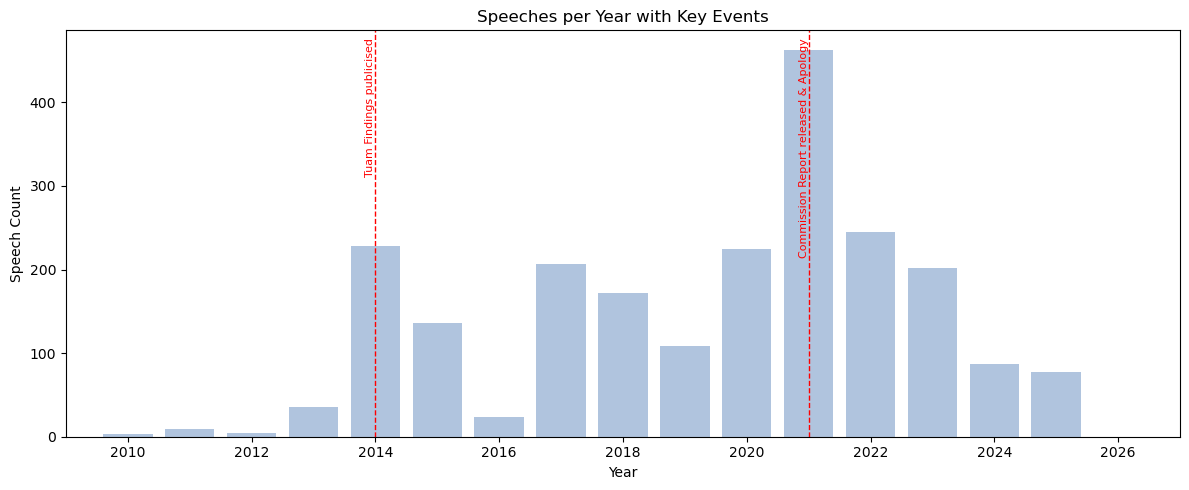

In [4]:
# Count speeches per year
# Convert to datetime first
df_mbh['date'] = pd.to_datetime(df_mbh['date'], errors='coerce')

# Count speeches per year
df_mbh['year'] = df_mbh['date'].dt.year
speeches_per_year = df_mbh.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart
ax.bar(speeches_per_year['year'], speeches_per_year['count'], 
       color='lightsteelblue', edgecolor='none', width=0.8)

# Key event vertical lines
ax.axvline(2014, color='red', linestyle='--', linewidth=1)
ax.axvline(2021, color='red', linestyle='--', linewidth=1)

# Rotated annotations
ax.text(2014, ax.get_ylim()[1] * 0.98, 'Tuam Findings publicised',
        rotation=90, va='top', ha='right', fontsize=8, color='red')
ax.text(2021, ax.get_ylim()[1] * 0.98, 'Commission Report released & Apology',
        rotation=90, va='top', ha='right', fontsize=8, color='red')

# Formatting
ax.set_xlabel('Year')
ax.set_ylabel('Speech Count')
ax.set_title('Speeches per Year with Key Events')
ax.set_xlim(2009, 2027)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.savefig('figures/speeches_per_year.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
len(df_baseline)

2224

In [6]:
len(df_mbh_stm)

452

In [7]:
df_mbh_stm.head()

,month,in_government,Regime,Score,Role
0,2010-11-01,0,Exploratory,0.682039,Opposition
1,2010-11-01,0,Managerial,0.192980,Opposition
2,2010-11-01,1,Exploratory,0.506657,Government
3,2010-11-01,1,Managerial,0.407030,Government
4,2011-06-01,1,Exploratory,0.283628,Government


In [8]:
df_mbh.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government',
       'word_count', 'parlasent_sentiment', 'sentences', 'text_for_sent',
       'parlasent_sentiment_sent', 'year'],
      dtype='str')

In [9]:
df_baseline.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'fullName', 'firstName', 'lastName', 'constituency',
       'party', 'membership_start', 'membership_end', 'gender_guess',
       'in_government', 'text_for_sent', 'sentences',
       'parlasent_sentiment_sent'],
      dtype='str')

In [10]:
df_baseline['parlasent_sentiment_sent'].mean()

np.float64(2.429488187122646)

In [11]:
df_mbh['date'] = pd.to_datetime(df_mbh['date'])
df_baseline['date'] = pd.to_datetime(df_baseline['date'])

# Survivor Similarity Scores
Survivors are mothers and babies born to them from the public QUOTE project.

In [12]:
folder_path = 'raw_data/Interviews'

In [13]:
## Functions needed
# Extract text from PDF
def extract_pdf_text(file_path):
    text = ""
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

# Extract speaker turns
def extract_speaker_turns(text):
    pattern = r'([A-Z]{1,3}):\s*(.*?)(?=\n[A-Z]{1,3}:|\Z)'
    matches = re.findall(pattern, text, re.DOTALL)
    
    data = []
    for speaker, speech in matches:
        data.append({
            "speaker": speaker.strip(),
            "text": speech.strip()
        })
    
    return data

# Keep only survivor speech
def filter_survivor_speech(speaker_data):
    interviewer_labels = ["OD", "IM"]
    
    survivor_texts = [
        entry["text"]
        for entry in speaker_data
        if entry["speaker"] not in interviewer_labels
    ]
    
    return survivor_texts

# Clean survivor speech
def clean_survivor_text(text_list):
    cleaned = []
    
    for text in text_list:
        # Remove line breaks inside text
        text = text.replace("\n", " ")
        
        # Remove multiple spaces
        text = re.sub(r"\s+", " ", text)
        
        # Remove standalone numbers (like page numbers)
        text = re.sub(r"\b\d+\b", "", text)
        
        cleaned.append(text.strip())
    
    return cleaned

# Filter out short sentences
def filter_short_sentences(sentences, min_words=3):
    return [s for s in sentences if len(s.split()) >= min_words]

# Split into sentences
def split_into_sentences(text_list):
    sentences = []
    for text in text_list:
        sentences.extend(sent_tokenize(text))
    return sentences

# Encode spech by sentences/tokens
def encode_speech_by_sentences(text, model):
    sents = sent_tokenize(re.sub(r'^.*?\n', '', str(text)))
    sents = [s for s in sents if len(s.strip()) > 10]
    if not sents:
        return np.zeros(768) # model putputs this vector of exactly 768 numbers for any input text
    embeddings = model.encode(sents)
    return np.mean(embeddings, axis=0)

In [14]:
RERUN_SIMILARITY = False  # Set to True to recompute (~5 min)

if RERUN_SIMILARITY:
    folder_path = 'raw_data/Interviews'

    # --- Extract survivor sentences from PDFs ---
    all_survivor_sentences = []
    for file in os.listdir(folder_path):
        if file.endswith(".pdf"):
            file_path = os.path.join(folder_path, file)
            raw_text = extract_pdf_text(file_path)
            speaker_data = extract_speaker_turns(raw_text)
            survivor_texts = filter_survivor_speech(speaker_data)
            cleaned_texts = clean_survivor_text(survivor_texts)
            sentences = split_into_sentences(cleaned_texts)
            sentences = filter_short_sentences(sentences) # min words = 3
            all_survivor_sentences.extend(sentences)
    print("Total survivor sentences:", len(all_survivor_sentences))

    # --- Encode and compute similarity ---
    model = SentenceTransformer('all-mpnet-base-v2')
    survivor_embeddings = model.encode(all_survivor_sentences, show_progress_bar=True)
    survivor_centroid = np.mean(survivor_embeddings, axis=0)

    speech_embeddings_sent = np.vstack([
        encode_speech_by_sentences(text, model) # with at least 10 characters
        for text in df_mbh['text']
    ])
    similarity_scores_sent = cosine_similarity(
        speech_embeddings_sent,
        survivor_centroid.reshape(1, -1)
    )
    df_mbh['survivor_similarity_sent'] = similarity_scores_sent.flatten()

    # --- Save full df ---
    df_mbh.to_csv('data/df_mbh_similarity_scores.csv', index=False)
    print("Saved df_mbh with similarity scores.")

else:
    df_mbh = pd.read_csv('data/df_mbh_similarity_scores.csv')
    df_mbh['date'] = pd.to_datetime(df_mbh['date'])
    print("Loaded df_mbh with similarity scores from CSV.")

Loaded df_mbh with similarity scores from CSV.


In [15]:
df_mbh.head()

,date,house_x,speaker,text,clean_text,text_length,speaker_norm,taoiseach_at_time,fullName,firstName,...,gender_guess,in_parliament,in_government,word_count,parlasent_sentiment,sentences,text_for_sent,parlasent_sentiment_sent,year,survivor_similarity_sent
0,2016-12-14,dail,Deputy Maureen O'Sullivan,deputy maureen o'sullivan\n my ques...,my question relates to a request f...,54,maureen o'sullivan,enda kenny,Maureen O'Sullivan,Maureen,...,female,yes,1,54,1.309223,[' my question relates to a request...,my question relates to a request f...,1.229268,2016,0.320948
1,2016-12-14,dail,Deputy Katherine Zappone,deputy katherine zappone\n i am awa...,i am aware of the request by the g...,306,katherine zappone,enda kenny,Katherine Zappone,Katherine,...,female,yes,1,306,1.997279,[' i am aware of the request by the...,i am aware of the request by the g...,2.280546,2016,0.253727
2,2016-12-14,dail,Deputy Maureen O'Sullivan,deputy maureen o'sullivan\n the nam...,the naming issue might seem like a...,146,maureen o'sullivan,enda kenny,Maureen O'Sullivan,Maureen,...,female,yes,1,146,2.290813,[' the naming issue might seem like...,the naming issue might seem like a...,2.214537,2016,0.463930
3,2016-11-17,seanad,Senator Máire Devine,senator máire devine\n i echo the poi...,i echo the points made by my colleag...,260,maire devine,enda kenny,Máire Devine,Máire,...,female,yes,0,260,0.000000,[' i echo the points made by my colle...,i echo the points made by my colleag...,1.298965,2016,0.443180
4,2016-11-17,dail,Deputy Ruth Coppinger,deputy ruth coppinger\n the programme...,the programme for government refers ...,157,ruth coppinger,enda kenny,Ruth Coppinger,Ruth,...,female,yes,0,157,0.405477,[' the programme for government refer...,the programme for government refers ...,1.074586,2016,0.238304


In [16]:
print("\nSentence-level aggregated similarity:")
print(df_mbh['survivor_similarity_sent'].describe())


Sentence-level aggregated similarity:
count    2224.000000
mean        0.373033
std         0.110619
min         0.074145
25%         0.292247
50%         0.366179
75%         0.443807
max         0.860474
Name: survivor_similarity_sent, dtype: float64


In [17]:
# Check if the gov vs opp pattern holds
print(df_mbh.groupby('in_government')['survivor_similarity_sent'].mean())

# Check pre/post 2021 split
df_mbh['year'] = pd.to_datetime(df_mbh['date']).dt.year
pre = df_mbh[df_mbh['year'] < 2021]
post = df_mbh[df_mbh['year'] >= 2021]

print("\nPre-2021:")
print(pre.groupby('in_government')['survivor_similarity_sent'].mean())
print("\nPost-2021:")
print(post.groupby('in_government')['survivor_similarity_sent'].mean())

in_government
0    0.384806
1    0.353635
Name: survivor_similarity_sent, dtype: float64

Pre-2021:
in_government
0    0.378670
1    0.354467
Name: survivor_similarity_sent, dtype: float64

Post-2021:
in_government
0    0.390614
1    0.352542
Name: survivor_similarity_sent, dtype: float64


In [18]:
# Statistics
gov_scores = df_mbh[df_mbh['in_government'] == 1]['survivor_similarity_sent']
opp_scores = df_mbh[df_mbh['in_government'] == 0]['survivor_similarity_sent']

t_stat, p_value = stats.ttest_ind(gov_scores, opp_scores)
print(f"Government mean: {gov_scores.mean():.4f}")
print(f"Opposition mean: {opp_scores.mean():.4f}")
print(f"Difference: {gov_scores.mean() - opp_scores.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

for period, mask in [('Pre-2021', df_mbh['date'].dt.year < 2021), 
                     ('Post-2021', df_mbh['date'].dt.year >= 2021)]:
    g = df_mbh[mask & (df_mbh['in_government'] == 1)]['survivor_similarity_sent']
    o = df_mbh[mask & (df_mbh['in_government'] == 0)]['survivor_similarity_sent']
    t, p = stats.ttest_ind(g, o)
    print(f"\n{period}")
    print(f"  Gov: {g.mean():.4f} | Opp: {o.mean():.4f} | diff: {g.mean()-o.mean():.4f} | p={p:.4f}")

Government mean: 0.3536
Opposition mean: 0.3848
Difference: -0.0312
t-statistic: -6.5021
p-value: 0.000000

Pre-2021
  Gov: 0.3545 | Opp: 0.3787 | diff: -0.0242 | p=0.0003

Post-2021
  Gov: 0.3525 | Opp: 0.3906 | diff: -0.0381 | p=0.0000


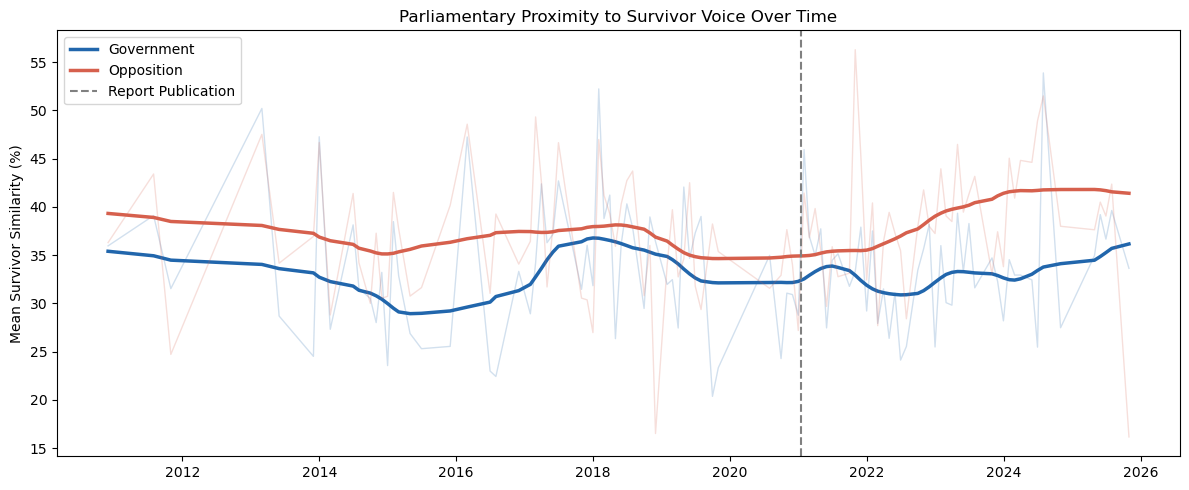

In [19]:
# Ensure datetime
df_mbh['date'] = pd.to_datetime(df_mbh['date'])

# Monthly grouped panel (same structure as sentiment)
ts_survivor = (
    df_mbh
    .groupby([pd.Grouper(key='date', freq='ME'), 'in_government'])['survivor_similarity_sent']
    .mean()
    .unstack()
) * 100

# Drop rows with missing values (important for LOWESS stability)
ts_survivor = ts_survivor.dropna()

# Time index for LOWESS
x = np.arange(len(ts_survivor))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for col, color, label in [
    (1, '#2166AC', 'Government'),
    (0, '#D6604D', 'Opposition')
]:
    raw = ts_survivor[col].values

    # LOWESS smoothing
    smooth = lowess(raw, x, frac=0.2)

    # Raw (faint)
    ax.plot(ts_survivor.index,
            raw,
            color=color,
            alpha=0.2,
            linewidth=1)

    # Smoothed (bold)
    ax.plot(ts_survivor.index,
            smooth[:, 1],
            color=color,
            linewidth=2.5,
            label=label)

# Event line
ax.axvline(pd.Timestamp('2021-01-12'),
           color='grey',
           linestyle='--',
           linewidth=1.5,
           label='Report Publication')

# Labels
ax.set_ylabel("Mean Survivor Similarity (%)")
ax.set_title("Parliamentary Proximity to Survivor Voice Over Time")
ax.legend()

plt.tight_layout()
plt.savefig("figures/survivor_similarity_lowess_all_speeches.png", dpi=300)
plt.show()

# Role Switchers Analysis

In [20]:
df_mbh.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government',
       'word_count', 'parlasent_sentiment', 'sentences', 'text_for_sent',
       'parlasent_sentiment_sent', 'year', 'survivor_similarity_sent'],
      dtype='str')

In [21]:
# See who the Independent speakers actually are
ind_gov = df_mbh[
    (df_mbh['party'] == 'Independent') & 
    (df_mbh['in_government'] == 1)
]['speaker_norm'].unique()

ind_opp = df_mbh[
    (df_mbh['party'] == 'Independent') & 
    (df_mbh['in_government'] == 0)
]['speaker_norm'].unique()

overlap_ind = set(ind_gov) & set(ind_opp)
print(f"Independent Gov speakers: {len(ind_gov)}")
print(f"  → {sorted(ind_gov)}")
print(f"\nIndependent Opp speakers: {len(ind_opp)}")
print(f"  → {sorted(ind_opp)}")
print(f"\nOverlap: {len(overlap_ind)}")
print(f"  → {overlap_ind}")

Independent Gov speakers: 21
  → ['alice-mary higgins', 'catherine connolly', 'colette kelleher', 'danny healy-rae', 'david p.b. norris', 'eileen flynn', 'finian mcgrath', 'frances black', 'gerard p. craughwell', 'joan freeman', 'katherine zappone', 'lynn ruane', "marie-louise o'donnell", 'mattie mcgrath', "maureen o'sullivan", 'michael collins', 'michael harty', 'ronan mullen', 'sean canney', 'thomas pringle', 'victor boyhan']

Independent Opp speakers: 34
  → ['alice-mary higgins', 'anne ferris', 'catherine connolly', 'clare daly', 'danny healy-rae', 'david p.b. norris', 'denis naughten', 'eileen flynn', 'fiach mac conghail', 'finian mcgrath', 'frances black', 'gerard p. craughwell', 'jillian van turnhout', 'joan collins', 'john halligan', 'katherine zappone', 'lynn ruane', 'marian harkin', 'mattie mcgrath', "maureen o'sullivan", 'michael collins', 'michael fitzmaurice', 'michael lowry', 'michael mcdowell', 'mick wallace', 'noel grealish', "richard o'donoghue", 'ronan mullen', 'sean 

In [22]:
# overlap of speakers in Fianna Fail and Labour Party that were both in government and opposition
for party in ['Fianna Fáil', 'Labour Party']:
    gov = df_mbh[
        (df_mbh['party'] == party) & 
        (df_mbh['in_government'] == 1)
    ]['speaker_norm'].unique()
    
    opp = df_mbh[
        (df_mbh['party'] == party) & 
        (df_mbh['in_government'] == 0)
    ]['speaker_norm'].unique()
    
    overlap = set(gov) & set(opp)
    print(f"\n{party}")
    print(f"  Gov speakers: {len(gov)}")
    print(f"  Opp speakers: {len(opp)}")
    print(f"  Overlap: {len(overlap)} → {overlap}")


Fianna Fáil
  Gov speakers: 32
  Opp speakers: 31
  Overlap: 16 → {'michael mcgrath', "fiona o'loughlin", 'niamh smyth', 'eamon o cuiv', 'sean o fearghail', 'mary butler', 'niall collins', "jennifer murnane o'connor", 'lorraine clifford-lee', 'catherine ardagh', 'lisa chambers', 'micheal martin', 'anne rabbitte', 'robert troy', "jim o'callaghan", 'stephen donnelly'}

Labour Party
  Gov speakers: 15
  Opp speakers: 19
  Overlap: 4 → {'kathleen lynch', 'aodhan o riordain', 'joan burton', 'ivana bacik'}


In [23]:
# Function for running the within speaker regression
def run_within_speaker_regression(df, outcome, group_name):
    """
    OLS with speaker fixed effects
    Tests whether in_government predicts outcome
    controlling for who the speaker is
    """
    model = smf.ols(
        f'{outcome} ~ in_government + C(speaker_norm)',
        data=df
    ).fit(cov_type='HC1')  # robust standard errors
    
    # Extract just the in_government coefficient
    coef  = model.params['in_government']
    se    = model.bse['in_government']
    pval  = model.pvalues['in_government']
    ci_lo = model.conf_int().loc['in_government', 0]
    ci_hi = model.conf_int().loc['in_government', 1]
    r2    = model.rsquared
    n     = int(model.nobs)
    
    print(f"\n{'='*50}")
    print(f"{group_name} — Outcome: {outcome}")
    print(f"{'='*50}")
    print(f"  N speeches:        {n}")
    print(f"  Coefficient:       {coef:.4f}")
    print(f"  Std Error:         {se:.4f}")
    print(f"  95% CI:            [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"  p-value:           {pval:.4f} {'***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''}")
    print(f"  R²:                {r2:.4f}")
    
    return {
        'group': group_name,
        'outcome': outcome,
        'coef': coef,
        'se': se,
        'pval': pval,
        'ci_lo': ci_lo,
        'ci_hi': ci_hi,
        'n': n,
        'significant': pval < 0.05
    }


In [24]:
# Find ALL speakers who appear in both government and opposition
# regardless of party
all_speakers_gov = df_mbh[df_mbh['in_government'] == 1]['speaker_norm'].unique()
all_speakers_opp = df_mbh[df_mbh['in_government'] == 0]['speaker_norm'].unique()

all_switchers_universal = set(all_speakers_gov) & set(all_speakers_opp)

print(f"Total speakers who switched: {len(all_switchers_universal)}")

# Check party breakdown of these switchers
switcher_parties = df_mbh[df_mbh['speaker_norm'].isin(all_switchers_universal)].groupby('party')['speaker_norm'].nunique().sort_values(ascending=False)
print(switcher_parties)

Total speakers who switched: 37
party
Independent     17
Fianna Fáil     16
Labour Party     4
Name: speaker_norm, dtype: int64


In [25]:
# Get all 37 switchers
all_overlap_universal = all_switchers_universal

# From theta (for STM outcomes)
all_theta = theta[theta['speaker_norm'].isin(all_overlap_universal)].copy()

# From df_mbh (for sentiment and similarity)
all_df = df_mbh[df_mbh['speaker_norm'].isin(all_overlap_universal)].copy()

print(f"Total switchers: {all_theta['speaker_norm'].nunique()} speakers, {len(all_theta)} speeches")
print(all_theta.groupby('in_government').size())

# Run pooled regression for all 4 outcomes
results_all = []
for outcome in ['Managerial', 'Exploratory']:
    results_all.append(
        run_within_speaker_regression(all_theta, outcome, 'All Switchers (37)')
    )
for outcome in ['parlasent_sentiment_sent', 'survivor_similarity_sent']:
    results_all.append(
        run_within_speaker_regression(all_df, outcome, 'All Switchers (37)')
    )

results_all_df = pd.DataFrame(results_all)
print("\n=== ALL SWITCHERS SUMMARY ===")
print(results_all_df[['group', 'outcome', 'coef', 'se', 'pval', 'significant']].to_string(index=False))

Total switchers: 37 speakers, 671 speeches
in_government
0    364
1    307
dtype: int64

All Switchers (37) — Outcome: Managerial
  N speeches:        671
  Coefficient:       0.0504
  Std Error:         0.0185
  95% CI:            [0.0142, 0.0866]
  p-value:           0.0063 **
  R²:                0.2780

All Switchers (37) — Outcome: Exploratory
  N speeches:        671
  Coefficient:       -0.0609
  Std Error:         0.0196
  95% CI:            [-0.0993, -0.0224]
  p-value:           0.0019 **
  R²:                0.3200

All Switchers (37) — Outcome: parlasent_sentiment_sent
  N speeches:        671
  Coefficient:       0.1964
  Std Error:         0.0553
  95% CI:            [0.0881, 0.3047]
  p-value:           0.0004 ***
  R²:                0.3362

All Switchers (37) — Outcome: survivor_similarity_sent
  N speeches:        671
  Coefficient:       0.0012
  Std Error:         0.0095
  95% CI:            [-0.0174, 0.0198]
  p-value:           0.9002 
  R²:                0.2430


### To be able to do the Mixed Effects Model Mutivariate Version in R:

In [26]:
# Check for duplicate combinations before merging
print(all_theta.groupby(['speaker_norm', 'in_government', 'date']).size().max())
print(all_df.groupby(['speaker_norm', 'in_government', 'date']).size().max())

8
8


In [27]:
all_theta.columns

Index(['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11',
       'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21',
       'T22', 'speaker_norm', 'party', 'in_government', 'date', 'Managerial',
       'Exploratory'],
      dtype='str')

In [28]:
all_df.columns

Index(['date', 'house_x', 'speaker', 'text', 'clean_text', 'text_length',
       'speaker_norm', 'taoiseach_at_time', 'fullName', 'firstName',
       'lastName', 'house_y', 'constituency', 'party', 'membership_start',
       'membership_end', 'gender_guess', 'in_parliament', 'in_government',
       'word_count', 'parlasent_sentiment', 'sentences', 'text_for_sent',
       'parlasent_sentiment_sent', 'year', 'survivor_similarity_sent'],
      dtype='str')

In [29]:
# Ensure date is datetime in both before merging
all_theta['date'] = pd.to_datetime(all_theta['date'])
all_df['date'] = pd.to_datetime(all_df['date'])

# Add a speech index within each speaker-date group to both dataframes
all_theta['speech_idx'] = all_theta.groupby(['speaker_norm', 'in_government', 'date']).cumcount()
all_df['speech_idx'] = all_df.groupby(['speaker_norm', 'in_government', 'date']).cumcount()

# Now merge on all four keys
all_combined = all_theta[['speaker_norm', 'in_government', 'date', 'speech_idx',
                           'Managerial', 'Exploratory']].merge(
    all_df[['speaker_norm', 'in_government', 'date', 'speech_idx',
            'parlasent_sentiment_sent', 'survivor_similarity_sent']],
    on=['speaker_norm', 'in_government', 'date', 'speech_idx'],
    how='inner'
)

print(all_combined.shape)  # should be 671
print(all_combined['speaker_norm'].nunique()) # should be 37
print(all_combined.head())
all_combined.to_csv('data/all_switchers_combined.csv', index=False)

(671, 8)
37
         speaker_norm  in_government       date  speech_idx  Managerial  \
0  maureen o'sullivan              1 2016-12-14           0    0.228297   
1   katherine zappone              1 2016-12-14           0    0.536071   
2  maureen o'sullivan              1 2016-12-14           1    0.416188   
3       victor boyhan              1 2016-11-16           0    0.524995   
4      thomas pringle              1 2016-11-03           0    0.170166   

   Exploratory  parlasent_sentiment_sent  survivor_similarity_sent  
0     0.524686                  1.229268                  0.320948  
1     0.272967                  2.280546                  0.253727  
2     0.420748                  2.214537                  0.463930  
3     0.381142                  2.530468                  0.342739  
4     0.788450                  1.027434                  0.323534  


# PHASE 3

### Granger Casuality

tests whether opposition scores contain information that helps predict future government scores beyond what government scores alone can predict. The reverse test is crucial — if government also Granger-causes opposition, you can't claim directional influence, just mutual dynamics.

In [30]:
# function: create consecutive quarterly series with interpolation
def make_consecutive(df, date_col, value_cols, start='2014Q1', end='2024Q4'):
    full_index = pd.period_range(start=start, end=end, freq='Q').to_timestamp()
    return (
        df[value_cols + [date_col]]
        .set_index(date_col)
        .reindex(full_index)
        .interpolate(method='linear')
        .reset_index()
        .rename(columns={'index': date_col})
    )

In [31]:
# 1. STM regime data
df_mbh_stm['month'] = pd.to_datetime(df_mbh_stm['month'])
df_mbh_stm['quarter'] = df_mbh_stm['month'].dt.to_period('Q').dt.to_timestamp()

regime_wide = (
    df_mbh_stm
    .groupby(['quarter', 'Regime', 'Role'])['Score']
    .mean()
    .reset_index()
    .pivot_table(index='quarter', columns=['Regime', 'Role'], values='Score')
    .reset_index()
)
regime_wide.columns = ['quarter', 'Exploratory_Gov', 'Exploratory_Opp',
                        'Managerial_Gov', 'Managerial_Opp']
regime_wide['Managerial_gap']  = regime_wide['Managerial_Gov']  - regime_wide['Managerial_Opp']
regime_wide['Exploratory_gap'] = regime_wide['Exploratory_Gov'] - regime_wide['Exploratory_Opp']



In [32]:
# Filter to 2014-2024 and interpolate
regime_wide = regime_wide[
    (regime_wide['quarter'] >= '2014-01-01') &
    (regime_wide['quarter'] <= '2024-12-31')
].sort_values('quarter')

regime_wide = make_consecutive(
    regime_wide, 'quarter',
    ['Exploratory_Gov', 'Exploratory_Opp', 'Managerial_Gov', 
     'Managerial_Opp', 'Managerial_gap', 'Exploratory_gap']
)

In [33]:
# 2. Survivor similarity quarterly
df_mbh['month'] = df_mbh['date'].dt.to_period('M')
df_mbh['month_dt'] = pd.to_datetime(df_mbh['month'].astype(str))
df_mbh['quarter']  = df_mbh['month_dt'].dt.to_period('Q').dt.to_timestamp()

sim_quarterly = (
    df_mbh.groupby(['quarter', 'in_government'])['survivor_similarity_sent']
    .mean()
    .reset_index()
    .pivot(index='quarter', columns='in_government', values='survivor_similarity_sent')
    .reset_index()
)
sim_quarterly.columns = ['quarter', 'sim_opp', 'sim_gov']
sim_quarterly['sim_gap'] = sim_quarterly['sim_gov'] - sim_quarterly['sim_opp']

sim_quarterly = sim_quarterly[
    (sim_quarterly['quarter'] >= '2014-01-01') &
    (sim_quarterly['quarter'] <= '2024-12-31')
]
sim_quarterly = make_consecutive(sim_quarterly, 'quarter', 
                                  ['sim_gov', 'sim_opp', 'sim_gap'])


In [34]:
# 3. Sentiment quarterly
sent_quarterly = (
    df_mbh.groupby(['quarter', 'in_government'])['parlasent_sentiment']
    .mean()
    .reset_index()
    .pivot(index='quarter', columns='in_government', values='parlasent_sentiment')
    .reset_index()
)
sent_quarterly.columns = ['quarter', 'sent_opp', 'sent_gov']
sent_quarterly['sent_gap'] = sent_quarterly['sent_gov'] - sent_quarterly['sent_opp']

sent_quarterly = sent_quarterly[
    (sent_quarterly['quarter'] >= '2014-01-01') &
    (sent_quarterly['quarter'] <= '2024-12-31')
]
sent_quarterly = make_consecutive(sent_quarterly, 'quarter',
                                   ['sent_gov', 'sent_opp', 'sent_gap'])

In [35]:
# 4. Verify all consecutive
print(f"Regime quarters:     {len(regime_wide)} (expected 44)")
print(f"Similarity quarters: {len(sim_quarterly)} (expected 44)")
print(f"Sentiment quarters:  {len(sent_quarterly)} (expected 44)")
print(f"Any NaN in regime:   {regime_wide.isna().sum().sum()}")
print(f"Any NaN in sim:      {sim_quarterly.isna().sum().sum()}")
print(f"Any NaN in sent:     {sent_quarterly.isna().sum().sum()}")

Regime quarters:     44 (expected 44)
Similarity quarters: 44 (expected 44)
Sentiment quarters:  44 (expected 44)
Any NaN in regime:   0
Any NaN in sim:      0
Any NaN in sent:     0


In [36]:
# Stationary check Augmented Dickey-Fuller test
for col in ['Managerial_Gov', 'Managerial_Opp', 'Exploratory_Gov', 'Exploratory_Opp']:
    result = adfuller(regime_wide[col])
    print(f"{col}: ADF={result[0]:.3f}, p={result[1]:.3f}")

for col in ['sim_gov', 'sim_opp']:
    result = adfuller(sim_quarterly[col])
    print(f"{col}: ADF={result[0]:.3f}, p={result[1]:.3f}")

for col in ['sent_gov', 'sent_opp']:
    result = adfuller(sent_quarterly[col])
    print(f"{col}: ADF={result[0]:.3f}, p={result[1]:.3f}")

Managerial_Gov: ADF=-5.410, p=0.000
Managerial_Opp: ADF=-4.973, p=0.000
Exploratory_Gov: ADF=-6.116, p=0.000
Exploratory_Opp: ADF=-4.449, p=0.000
sim_gov: ADF=-7.771, p=0.000
sim_opp: ADF=-5.650, p=0.000
sent_gov: ADF=-5.710, p=0.000
sent_opp: ADF=-1.360, p=0.601


In [37]:
# GRANGER CAUSALITY (2014Q1-2024Q4, consecutive quarterly)

# Test 1: Does opposition similarity predict government similarity?
print("\n=== Does Opposition Similarity predict Government Similarity? ===")
granger_sim = grangercausalitytests(
    sim_quarterly[['sim_gov', 'sim_opp']],
    maxlag=3, verbose=True
)

# # Test 2: Does opposition sentiment predict government sentiment?
# print("\n=== Does Opposition Sentiment predict Government Sentiment? ===")
# granger_sent = grangercausalitytests(
#     sent_quarterly[['sent_gov', 'sent_opp']],
#     maxlag=3, verbose=True
# )

# Test 3: Does opposition managerial score predict government managerial score?
print("\n=== Does Opposition Managerial Score predict Government Managerial Score? ===")
granger_man = grangercausalitytests(
    regime_wide[['Managerial_Gov', 'Managerial_Opp']],
    maxlag=3, verbose=True
)

# Test 4: Does opposition exploratory score predict government exploratory score?
print("\n=== Does Opposition Exploratory Score predict Government Exploratory Score? ===")
granger_exp = grangercausalitytests(
    regime_wide[['Exploratory_Gov', 'Exploratory_Opp']],
    maxlag=3, verbose=True
)

# Test 5: Reverse falsification — does government predict opposition?
print("\n=== REVERSE FALSIFICATION: Does Government Similarity predict Opposition? ===")
granger_reverse_sim = grangercausalitytests(
    sim_quarterly[['sim_opp', 'sim_gov']],
    maxlag=3, verbose=True
)

# # Test 6: Does Government Sentiment predict Opposition Sentiment?
# print("\n=== REVERSE: Does Government Sentiment predict Opposition Sentiment? ===")
# granger_reverse_sent = grangercausalitytests(
#     sent_quarterly[['sent_opp', 'sent_gov']],
#     maxlag=3, verbose=True
# )

# Test 7
print("\n=== REVERSE FALSIFICATION: Does Government Managerial predict Opposition? ===")
granger_reverse_man = grangercausalitytests(
    regime_wide[['Managerial_Opp', 'Managerial_Gov']],
    maxlag=3, verbose=True
)

# Test 8: 
print("\n=== REVERSE: Does Government Exploratory predict Opposition Exploratory? ===")
granger_reverse_exp = grangercausalitytests(
    regime_wide[['Exploratory_Opp', 'Exploratory_Gov']],
    maxlag=3, verbose=True
)




=== Does Opposition Similarity predict Government Similarity? ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6700  , p=0.4179  , df_denom=40, df_num=1
ssr based chi2 test:   chi2=0.7203  , p=0.3961  , df=1
likelihood ratio test: chi2=0.7143  , p=0.3980  , df=1
parameter F test:         F=0.6700  , p=0.4179  , df_denom=40, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4538  , p=0.6387  , df_denom=37, df_num=2
ssr based chi2 test:   chi2=1.0302  , p=0.5975  , df=2
likelihood ratio test: chi2=1.0177  , p=0.6012  , df=2
parameter F test:         F=0.4538  , p=0.6387  , df_denom=37, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6020  , p=0.6182  , df_denom=34, df_num=3
ssr based chi2 test:   chi2=2.1779  , p=0.5363  , df=3
likelihood ratio test: chi2=2.1220  , p=0.5475  , df=3
parameter F test:         F=0.6020  , p=0.6182  , df_denom=34, df_num=3

=== Does Opposition Managerial S

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/ts

In [38]:
# Additional cross-series tests
print("\n=== Does Government Managerial predict Opposition Exploratory? ===")
grangercausalitytests(
    regime_wide[['Exploratory_Opp', 'Managerial_Gov']],
    maxlag=3, verbose=True
)

print("\n=== Does Government Exploratory predict Opposition Managerial? ===")
grangercausalitytests(
    regime_wide[['Managerial_Opp', 'Exploratory_Gov']],
    maxlag=3, verbose=True
)

# print("\n=== Does Government Managerial predict Opposition Sentiment? ===")
# grangercausalitytests(
#     sent_quarterly[['sent_opp', 'sent_gov']],
#     maxlag=3, verbose=True
# )

# print("\n=== Does Government Exploratory predict Opposition Sentiment? ===")
# grangercausalitytests(
#     pd.concat([sent_quarterly['sent_opp'], regime_wide['Exploratory_Gov']], axis=1),
#     maxlag=3, verbose=True
# )

print("\n=== Does Opposition Managerial predict Government Exploratory? ===")
grangercausalitytests(
    regime_wide[['Exploratory_Gov', 'Managerial_Opp']],
    maxlag=3, verbose=True
)

print("\n=== Does Opposition Exploratory predict Government Managerial? ===")
grangercausalitytests(
    regime_wide[['Managerial_Gov', 'Exploratory_Opp']],
    maxlag=3, verbose=True
)

print("\n=== Does Opposition Similarity predict Government Managerial? ===")
grangercausalitytests(
    pd.concat([regime_wide['Managerial_Gov'], sim_quarterly['sim_opp']], axis=1).dropna(),
    maxlag=3, verbose=True
)

print("\n=== Does Opposition Similarity predict Government Exploratory? ===")
grangercausalitytests(
    pd.concat([regime_wide['Exploratory_Gov'], sim_quarterly['sim_opp']], axis=1).dropna(),
    maxlag=3, verbose=True
)

print("\n=== Does Government Managerial predict Opposition Similarity? ===")
grangercausalitytests(
    pd.concat([sim_quarterly['sim_opp'], regime_wide['Managerial_Gov']], axis=1).dropna(),
    maxlag=3, verbose=True
)

print("\n=== Does Government Exploratory predict Opposition Similarity? ===")
grangercausalitytests(
    pd.concat([sim_quarterly['sim_opp'], regime_wide['Exploratory_Gov']], axis=1).dropna(),
    maxlag=3, verbose=True
)


=== Does Government Managerial predict Opposition Exploratory? ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.0336  , p=0.0514  , df_denom=40, df_num=1
ssr based chi2 test:   chi2=4.3361  , p=0.0373  , df=1
likelihood ratio test: chi2=4.1312  , p=0.0421  , df=1
parameter F test:         F=4.0336  , p=0.0514  , df_denom=40, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.7534  , p=0.0145  , df_denom=37, df_num=2
ssr based chi2 test:   chi2=10.7916 , p=0.0045  , df=2
likelihood ratio test: chi2=9.6046  , p=0.0082  , df=2
parameter F test:         F=4.7534  , p=0.0145  , df_denom=37, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4044  , p=0.0285  , df_denom=34, df_num=3
ssr based chi2 test:   chi2=12.3161 , p=0.0064  , df=3
likelihood ratio test: chi2=10.7693 , p=0.0130  , df=3
parameter F test:         F=3.4044  , p=0.0285  , df_denom=34, df_num=3

=== Does Government Exploratory

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(0.057209168793171776),
    np.float64(0.8121839412446025),
    np.float64(40.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.06149985645265966),
    np.float64(0.8041408705298108),
    np.int64(1)),
   'lrtest': (np.float64(0.06145591889566049),
    np.float64(0.8042094251543397),
    np.int64(1)),
   'params_ftest': (np.float64(0.05720916879316258),
    np.float64(0.8121839412446173),
    np.float64(40.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.36234336213004137),
    np.float64(0.698485699297119),
    np.float64(37.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.8226173626736075),
    np.float64(0.6627823114912268),
    np.int64(2)),
   'lrtest': (np.float64(0.8146650867871017),
    np.float64(0.6654228715246692),
    np.int64(2)),
   'params_ftest': (np.float64(0.36234336213004487),
    np.float64(0.6984856992971167),
    np.float64(37.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
    

In [39]:
# 1. Collect all p-values from Granger results, use the SSR-based F-test p-value

def get_pvals(result_dict, maxlag=3):
    """Extract SSR F-test p-values for lags 1 to maxlag."""
    return [result_dict[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag+1)]

# Opposition → Government tests
opp_to_gov_tests = {
    'Opp Similarity → Gov Similarity':    get_pvals(granger_sim),
    'Opp Managerial → Gov Managerial':    get_pvals(granger_man),
    'Opp Exploratory → Gov Exploratory':  get_pvals(granger_exp),
    'Opp Managerial → Gov Exploratory':   get_pvals(
        grangercausalitytests(
            regime_wide[['Exploratory_Gov', 'Managerial_Opp']],
            maxlag=3, verbose=False)),
    'Opp Exploratory → Gov Managerial':   get_pvals(
        grangercausalitytests(
            regime_wide[['Managerial_Gov', 'Exploratory_Opp']],
            maxlag=3, verbose=False)),
    'Opp Similarity → Gov Managerial':    get_pvals(
        grangercausalitytests(
            pd.concat([regime_wide['Managerial_Gov'], 
                      sim_quarterly['sim_opp']], axis=1).dropna(),
            maxlag=3, verbose=False)),
    'Opp Similarity → Gov Exploratory':   get_pvals(
        grangercausalitytests(
            pd.concat([regime_wide['Exploratory_Gov'], 
                      sim_quarterly['sim_opp']], axis=1).dropna(),
            maxlag=3, verbose=False)),
}

# Government → Opposition tests
gov_to_opp_tests = {
    'Gov Similarity → Opp Similarity':    get_pvals(granger_reverse_sim),
    'Gov Managerial → Opp Managerial':    get_pvals(granger_reverse_man),
    'Gov Exploratory → Opp Exploratory':  get_pvals(granger_reverse_exp),
    'Gov Managerial → Opp Exploratory':   get_pvals(
        grangercausalitytests(
            regime_wide[['Exploratory_Opp', 'Managerial_Gov']],
            maxlag=3, verbose=False)),
    'Gov Exploratory → Opp Managerial':   get_pvals(
        grangercausalitytests(
            regime_wide[['Managerial_Opp', 'Exploratory_Gov']],
            maxlag=3, verbose=False)),
    'Gov Managerial → Opp Similarity':    get_pvals(
        grangercausalitytests(
            pd.concat([sim_quarterly['sim_opp'], 
                      regime_wide['Managerial_Gov']], axis=1).dropna(),
            maxlag=3, verbose=False)),
    'Gov Exploratory → Opp Similarity':   get_pvals(
        grangercausalitytests(
            pd.concat([sim_quarterly['sim_opp'], 
                      regime_wide['Exploratory_Gov']], axis=1).dropna(),
            maxlag=3, verbose=False)),
}


# 2. Apply BH correction within each directional block

def apply_bh(tests_dict, block_name):
    rows = []
    for test_name, pvals in tests_dict.items():
        for lag, p in enumerate(pvals, start=1):
            rows.append({'test': test_name, 'lag': lag, 'p_raw': p})
    
    df = pd.DataFrame(rows)
    
    # BH correction across all tests in this block
    reject, p_adj, _, _ = multipletests(df['p_raw'], method='fdr_bh', alpha=0.05)
    df['p_adj'] = p_adj
    df['reject_H0'] = reject
    df['sig_raw'] = df['p_raw'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 
                  else '*' if p < 0.05 else '')
    df['sig_adj'] = df['p_adj'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 
                  else '*' if p < 0.05 else '')
    
    print(f"\n{'='*60}")
    print(f"Block: {block_name}")
    print(f"{'='*60}")
    print(df[['test', 'lag', 'p_raw', 'sig_raw', 
              'p_adj', 'sig_adj', 'reject_H0']].to_string(index=False))
    
    return df

df_opp_gov = apply_bh(opp_to_gov_tests, 'Opposition → Government')
df_gov_opp = apply_bh(gov_to_opp_tests, 'Government → Opposition')


# Summary: which tests survive BH correction?

print("\n=== TESTS SURVIVING BH CORRECTION ===")
all_results = pd.concat([df_opp_gov, df_gov_opp])
surviving = all_results[all_results['reject_H0']]
print(surviving[['test', 'lag', 'p_raw', 'p_adj']].to_string(index=False))


Block: Opposition → Government
                             test  lag    p_raw sig_raw    p_adj sig_adj  reject_H0
  Opp Similarity → Gov Similarity    1 0.417891         0.940048              False
  Opp Similarity → Gov Similarity    2 0.638725         0.940048              False
  Opp Similarity → Gov Similarity    3 0.618164         0.940048              False
  Opp Managerial → Gov Managerial    1 0.634487         0.940048              False
  Opp Managerial → Gov Managerial    2 0.502587         0.940048              False
  Opp Managerial → Gov Managerial    3 0.302913         0.940048              False
Opp Exploratory → Gov Exploratory    1 0.377471         0.940048              False
Opp Exploratory → Gov Exploratory    2 0.959029         0.959029              False
Opp Exploratory → Gov Exploratory    3 0.826735         0.940048              False
 Opp Managerial → Gov Exploratory    1 0.335463         0.940048              False
 Opp Managerial → Gov Exploratory    2 0.588

/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## Change Point Analysis (Phase 2) - GO To R!
Use the df saved below for the analysis in R

In [40]:
# df for Multivariate Change Point Analysis in R
# Aggregate to quarterly level before exporting
df_mbh_quarterly = (
    df_mbh.groupby(['quarter', 'in_government'])
    .agg(
        parlasent_sentiment = ('parlasent_sentiment_sent', 'mean'),
        survivor_similarity = ('survivor_similarity_sent', 'mean'),
        speech_count        = ('clean_text', 'count')
    )
    .reset_index()
)

df_mbh_quarterly.to_csv('data/df_mbh_quarterly.csv', index=False)
print(df_mbh_quarterly.head())
print(f"Exported {len(df_mbh_quarterly)} rows")

     quarter  in_government  parlasent_sentiment  survivor_similarity  \
0 2010-10-01              0             1.942087             0.363009   
1 2010-10-01              1             2.103628             0.359625   
2 2011-04-01              1             2.496033             0.363570   
3 2011-07-01              0             1.186539             0.434120   
4 2011-07-01              1             2.846759             0.391073   

   speech_count  
0             1  
1             2  
2             1  
3             2  
4             1  
Exported 105 rows
